# TTPLA Torchvision Mask R-CNN Trainer

Notebook ini melatih Mask R-CNN untuk segmentasi instance TTPLA dengan PyTorch dan Torchvision murni.

Pipeline utama:
1. Membaca anotasi COCO JSON secara langsung.
2. Membuat `Dataset`, `DataLoader`, dan `collate_fn` native PyTorch.
3. Menggunakan `MaskRCNN_ResNet50_FPN_Weights.DEFAULT`.
4. Melatih model dengan custom training loop.
5. Mengevaluasi model dengan `pycocotools`.
6. Menyimpan output sederhana di folder `outputs/`.

## 1. Instalasi Library

Jalankan cell ini saat environment belum memiliki library yang dibutuhkan.

In [1]:
# Jalankan jika environment belum lengkap.
# Di Google Colab, cell ini aman dijalankan langsung.
%pip install -q torch torchvision pycocotools matplotlib pillow tqdm gdown albumentations opencv-python

## 2. Import dan Konfigurasi Dasar

In [2]:
from pathlib import Path
import json
import random
import shutil
import warnings

import gdown
import numpy as np
import torch
import torchvision
import albumentations as A

from PIL import Image
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
from matplotlib import patches

from torch.utils.data import Dataset, DataLoader

from torchvision.models.detection import (
    maskrcnn_resnet50_fpn,
    MaskRCNN_ResNet50_FPN_Weights
)
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor

from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from pycocotools import mask as mask_utils

warnings.filterwarnings("ignore", category=UserWarning)


def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [ ]:
DATASET_ROOT = Path("./data/ttpla-dataset")
TRAIN_IMAGES_DIR = DATASET_ROOT / "trainingset"
TRAIN_ANN_PATH = TRAIN_IMAGES_DIR / "train.json"
TEST_IMAGES_DIR = DATASET_ROOT / "testset"
TEST_ANN_PATH = TEST_IMAGES_DIR / "test.json"

OUTPUT_DIR = Path("outputs")
PREDICTION_DIR = OUTPUT_DIR / "predictions"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PREDICTION_DIR.mkdir(parents=True, exist_ok=True)

BATCH_SIZE = 4
NUM_EPOCHS = 15
LEARNING_RATE = 0.001
MOMENTUM = 0.9
WEIGHT_DECAY = 0.0005
NUM_WORKERS = 2
EVAL_EVERY = 1
SCORE_THRESHOLD = 0.50
MASK_THRESHOLD = 0.50

print("Dataset root:", DATASET_ROOT)
print("Output dir:", OUTPUT_DIR)

Dataset root: data/ttpla-dataset
Output dir: outputs


## 3. Unduh Dataset TTPLA

In [4]:
# Jalankan cell ini jika dataset belum tersedia di DATASET_ROOT.
# Struktur yang diharapkan:
# data/ttpla-dataset/
# ├── trainingset/train.json
# └── testset/test.json

DATASET_GDRIVE_ID = "1t4ZCts89QfMgsqhJq9Jkmm-VofpgeWCT"

def download_ttpla_dataset(dataset_root: Path, gdrive_id: str) -> None:
    dataset_root.mkdir(parents=True, exist_ok=True)
    train_json = dataset_root / "trainingset" / "train.json"
    test_json = dataset_root / "testset" / "test.json"

    if train_json.exists() and test_json.exists():
        print("Dataset sudah tersedia.")
        return

    zip_path = dataset_root / "ttpla-dataset.zip"
    url = f"https://drive.google.com/uc?id={gdrive_id}"

    print("Mengunduh dataset...")
    gdown.download(url, str(zip_path), quiet=False, fuzzy=True)

    print("Mengekstrak dataset...")
    shutil.unpack_archive(str(zip_path), str(dataset_root), "zip")
    zip_path.unlink(missing_ok=True)

    print("Selesai:", dataset_root)


download_ttpla_dataset(DATASET_ROOT, DATASET_GDRIVE_ID)

Mengunduh dataset...


Downloading...
From (original): https://drive.google.com/uc?id=1t4ZCts89QfMgsqhJq9Jkmm-VofpgeWCT
From (redirected): https://drive.google.com/uc?id=1t4ZCts89QfMgsqhJq9Jkmm-VofpgeWCT&confirm=t&uuid=21582071-e540-45f2-86b1-42470be957b1
To: /content/data/ttpla-dataset/ttpla-dataset.zip
100%|██████████| 291M/291M [00:10<00:00, 27.4MB/s] 


Mengekstrak dataset...
Selesai: data/ttpla-dataset


## 4. Dataset COCO Native PyTorch

In [5]:
def load_coco_categories(annotation_path: Path) -> dict:
    with open(annotation_path, "r", encoding="utf-8") as file:
        data = json.load(file)

    cat_ids = sorted(category["id"] for category in data["categories"])
    cat_id_to_label = {cat_id: index + 1 for index, cat_id in enumerate(cat_ids)}
    label_to_cat_id = {label: cat_id for cat_id, label in cat_id_to_label.items()}
    label_names = {
        cat_id_to_label[category["id"]]: category["name"]
        for category in data["categories"]
    }

    return {
        "cat_ids": cat_ids,
        "cat_id_to_label": cat_id_to_label,
        "label_to_cat_id": label_to_cat_id,
        "label_names": label_names
    }


def collate_fn(batch):
    images, targets = zip(*batch)
    return list(images), list(targets)


class CocoMaskDataset(Dataset):
    def __init__(
        self,
        images_dir: Path,
        annotation_path: Path,
        transforms=None,
        drop_empty: bool = False
    ):
        self.images_dir = Path(images_dir)
        self.annotation_path = Path(annotation_path)
        self.transforms = transforms

        self.coco = COCO(str(self.annotation_path))
        self.image_ids = sorted(self.coco.getImgIds())

        categories = load_coco_categories(self.annotation_path)
        self.cat_ids = categories["cat_ids"]
        self.cat_id_to_label = categories["cat_id_to_label"]
        self.label_to_cat_id = categories["label_to_cat_id"]
        self.label_names = categories["label_names"]

        if drop_empty:
            self.image_ids = [
                image_id
                for image_id in self.image_ids
                if len(self._valid_annotations(image_id)) > 0
            ]

    def _valid_annotations(self, image_id: int) -> list:
        annotation_ids = self.coco.getAnnIds(imgIds=image_id)
        annotations = self.coco.loadAnns(annotation_ids)

        valid_annotations = []
        for annotation in annotations:
            x, y, width, height = annotation.get("bbox", [0, 0, 0, 0])
            area = annotation.get("area", width * height)

            if width > 1 and height > 1 and area > 1:
                valid_annotations.append(annotation)

        return valid_annotations

    def __len__(self) -> int:
        return len(self.image_ids)

    def __getitem__(self, index: int):
        image_id = self.image_ids[index]
        image_info = self.coco.loadImgs(image_id)[0]
        image_path = self.images_dir / image_info["file_name"]

        image = np.array(Image.open(image_path).convert("RGB"))
        height, width = image.shape[:2]

        annotations = self._valid_annotations(image_id)

        boxes_coco = []
        masks = []
        labels = []
        iscrowds = []

        for annotation in annotations:
            x, y, box_width, box_height = annotation["bbox"]
            boxes_coco.append([x, y, box_width, box_height])
            masks.append(self.coco.annToMask(annotation))
            labels.append(self.cat_id_to_label[annotation["category_id"]])
            iscrowds.append(annotation.get("iscrowd", 0))

        if self.transforms is not None and len(boxes_coco) > 0:
            transformed = self.transforms(
                image=image,
                masks=masks,
                bboxes=boxes_coco,
                category_ids=labels,
                iscrowds=iscrowds
            )
            image = transformed["image"]
            masks = transformed["masks"]
            boxes_coco = transformed["bboxes"]
            labels = transformed["category_ids"]
            iscrowds = transformed["iscrowds"]

        boxes_xyxy = []
        valid_masks = []
        valid_labels = []
        valid_iscrowds = []
        valid_areas = []

        for box, mask, label, iscrowd in zip(boxes_coco, masks, labels, iscrowds):
            x, y, box_width, box_height = box
            x1 = max(0.0, float(x))
            y1 = max(0.0, float(y))
            x2 = min(float(image.shape[1]), x1 + float(box_width))
            y2 = min(float(image.shape[0]), y1 + float(box_height))

            mask_array = np.asarray(mask, dtype=np.uint8)

            if x2 <= x1 or y2 <= y1:
                continue

            if mask_array.sum() == 0:
                continue

            boxes_xyxy.append([x1, y1, x2, y2])
            valid_masks.append(mask_array)
            valid_labels.append(int(label))
            valid_iscrowds.append(int(iscrowd))
            valid_areas.append(float(mask_array.sum()))

        if len(boxes_xyxy) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            target_labels = torch.zeros((0,), dtype=torch.int64)
            target_masks = torch.zeros((0, height, width), dtype=torch.uint8)
            target_areas = torch.zeros((0,), dtype=torch.float32)
            target_iscrowds = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.as_tensor(boxes_xyxy, dtype=torch.float32)
            target_labels = torch.as_tensor(valid_labels, dtype=torch.int64)
            target_masks = torch.as_tensor(np.stack(valid_masks), dtype=torch.uint8)
            target_areas = torch.as_tensor(valid_areas, dtype=torch.float32)
            target_iscrowds = torch.as_tensor(valid_iscrowds, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": target_labels,
            "masks": target_masks,
            "image_id": torch.tensor([image_id], dtype=torch.int64),
            "area": target_areas,
            "iscrowd": target_iscrowds
        }

        image_tensor = torchvision.transforms.functional.to_tensor(image.copy())
        return image_tensor, target

## 5. Augmentasi dan DataLoader

In [6]:
train_transforms = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.3),
        A.RandomBrightnessContrast(
            brightness_limit=0.2,
            contrast_limit=0.2,
            p=0.5
        ),
        A.RGBShift(
            r_shift_limit=15,
            g_shift_limit=15,
            b_shift_limit=15,
            p=0.3
        ),
        A.Blur(
            blur_limit=(3, 5),
            p=0.2
        )
    ],
    bbox_params=A.BboxParams(
        format="coco",
        label_fields=["category_ids", "iscrowds"],
        min_area=4,
        min_visibility=0.1,
        clip=True
    )
)

train_dataset = CocoMaskDataset(
    images_dir=TRAIN_IMAGES_DIR,
    annotation_path=TRAIN_ANN_PATH,
    transforms=train_transforms,
    drop_empty=True
)

test_dataset = CocoMaskDataset(
    images_dir=TEST_IMAGES_DIR,
    annotation_path=TEST_ANN_PATH,
    transforms=None,
    drop_empty=False
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn
)

NUM_CLASSES = len(train_dataset.cat_ids) + 1

print("Jumlah train:", len(train_dataset))
print("Jumlah test:", len(test_dataset))
print("Jumlah kelas termasuk background:", NUM_CLASSES)
print("Label names:", train_dataset.label_names)

loading annotations into memory...
Done (t=0.14s)
creating index...
index created!
loading annotations into memory...
Done (t=0.07s)
creating index...
index created!
Jumlah train: 842
Jumlah test: 400
Jumlah kelas termasuk background: 5
Label names: {1: 'cable', 2: 'tower_lattice', 3: 'tower_tucohy', 4: 'tower_wooden'}


## 6. Visualisasi Sampel Dataset

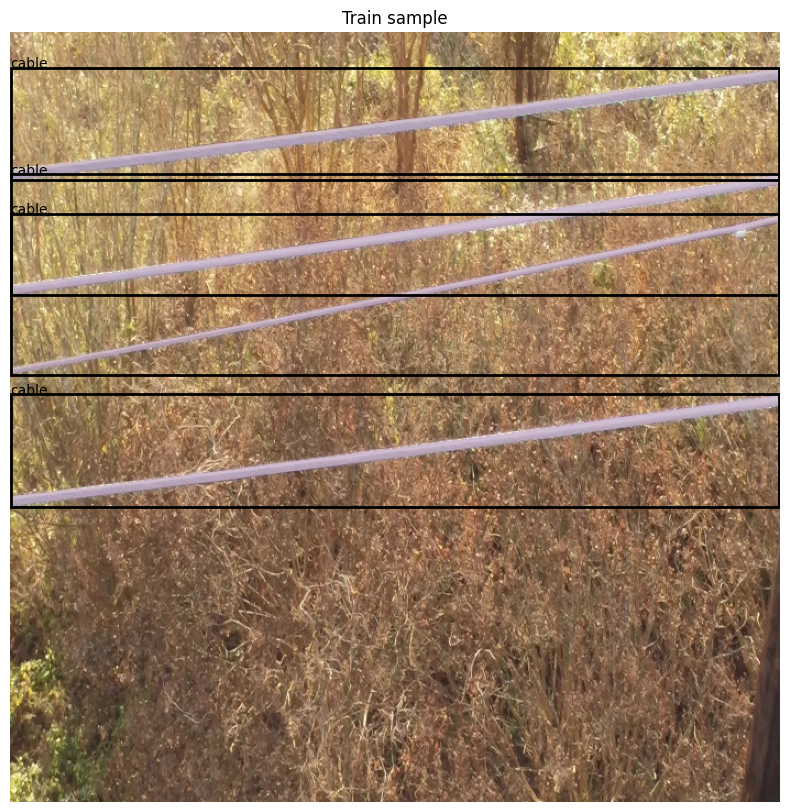

In [7]:
def draw_target(image_tensor, target, label_names: dict, title: str = "Sample"):
    image = image_tensor.permute(1, 2, 0).cpu().numpy()

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(image)
    ax.set_title(title)
    ax.axis("off")

    boxes = target["boxes"].cpu().numpy()
    labels = target["labels"].cpu().numpy()
    masks = target["masks"].cpu().numpy()

    for box, label, mask in zip(boxes, labels, masks):
        x1, y1, x2, y2 = box
        rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            fill=False,
            linewidth=2
        )
        ax.add_patch(rect)

        class_name = label_names.get(int(label), str(label))
        ax.text(x1, y1, class_name, fontsize=10)

        masked = np.ma.masked_where(mask == 0, mask)
        ax.imshow(masked, alpha=0.25)

    plt.show()


sample_image, sample_target = train_dataset[0]
draw_target(
    image_tensor=sample_image,
    target=sample_target,
    label_names=train_dataset.label_names,
    title="Train sample"
)

## 7. Model Torchvision Mask R-CNN

In [8]:
def build_mask_rcnn_model(num_classes: int):
    weights = MaskRCNN_ResNet50_FPN_Weights.DEFAULT

    model = maskrcnn_resnet50_fpn(
        weights=weights
    )

    in_features_box = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(
        in_features_box,
        num_classes
    )

    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256
    model.roi_heads.mask_predictor = MaskRCNNPredictor(
        in_features_mask,
        hidden_layer,
        num_classes
    )

    return model


model = build_mask_rcnn_model(NUM_CLASSES).to(DEVICE)

params = [parameter for parameter in model.parameters() if parameter.requires_grad]

optimizer = torch.optim.SGD(
    params,
    lr=LEARNING_RATE,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY
)

lr_scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.1
)

print(model.__class__.__name__)

Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:00<00:00, 186MB/s] 


MaskRCNN


## 8. Evaluasi COCO dengan pycocotools

In [9]:
def encode_binary_mask(binary_mask: np.ndarray) -> dict:
    rle = mask_utils.encode(
        np.asfortranarray(binary_mask.astype(np.uint8))
    )
    rle["counts"] = rle["counts"].decode("utf-8")
    return rle


def convert_predictions_to_coco_results(
    predictions: list,
    targets: list,
    label_to_cat_id: dict,
    score_threshold: float = 0.5,
    mask_threshold: float = 0.5
) -> list:
    results = []

    for prediction, target in zip(predictions, targets):
        image_id = int(target["image_id"].item())

        boxes = prediction["boxes"].detach().cpu().numpy()
        scores = prediction["scores"].detach().cpu().numpy()
        labels = prediction["labels"].detach().cpu().numpy()
        masks = prediction["masks"].detach().cpu().numpy()

        for box, score, label, mask in zip(boxes, scores, labels, masks):
            if float(score) < score_threshold:
                continue

            x1, y1, x2, y2 = box.tolist()
            width = max(0.0, x2 - x1)
            height = max(0.0, y2 - y1)

            if width <= 0 or height <= 0:
                continue

            binary_mask = mask[0] >= mask_threshold

            if binary_mask.sum() == 0:
                continue

            results.append(
                {
                    "image_id": image_id,
                    "category_id": int(label_to_cat_id[int(label)]),
                    "bbox": [
                        float(x1),
                        float(y1),
                        float(width),
                        float(height)
                    ],
                    "score": float(score),
                    "segmentation": encode_binary_mask(binary_mask)
                }
            )

    return results


def evaluate_coco(
    model,
    data_loader,
    dataset: CocoMaskDataset,
    device,
    score_threshold: float = 0.05,
    mask_threshold: float = 0.5
) -> dict:
    model.eval()
    coco_results = []

    with torch.no_grad():
        for images, targets in tqdm(data_loader, desc="Evaluating"):
            images = [image.to(device) for image in images]
            predictions = model(images)

            batch_results = convert_predictions_to_coco_results(
                predictions=predictions,
                targets=targets,
                label_to_cat_id=dataset.label_to_cat_id,
                score_threshold=score_threshold,
                mask_threshold=mask_threshold
            )
            coco_results.extend(batch_results)

    if len(coco_results) == 0:
        return {
            "bbox": {"AP": 0.0, "AP50": 0.0, "AP75": 0.0},
            "segm": {"AP": 0.0, "AP50": 0.0, "AP75": 0.0}
        }

    coco_gt = dataset.coco
    coco_dt = coco_gt.loadRes(coco_results)

    metric_names = [
        "AP", "AP50", "AP75", "AP_small", "AP_medium", "AP_large",
        "AR_1", "AR_10", "AR_100", "AR_small", "AR_medium", "AR_large"
    ]

    summary = {}

    for iou_type in ["bbox", "segm"]:
        coco_eval = COCOeval(coco_gt, coco_dt, iouType=iou_type)
        coco_eval.evaluate()
        coco_eval.accumulate()
        coco_eval.summarize()

        summary[iou_type] = {
            name: float(value)
            for name, value in zip(metric_names, coco_eval.stats)
        }

    return summary

## 9. Custom Training Loop

In [10]:
def move_targets_to_device(targets: list, device) -> list:
    return [
        {
            key: value.to(device) if torch.is_tensor(value) else value
            for key, value in target.items()
        }
        for target in targets
    ]


def train_one_epoch(model, optimizer, data_loader, device, epoch: int) -> dict:
    model.train()

    total_loss = 0.0
    loss_totals = {}
    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch}")

    for images, targets in progress_bar:
        images = [image.to(device) for image in images]
        targets = move_targets_to_device(targets, device)

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        if not torch.isfinite(losses):
            raise RuntimeError(f"Loss tidak finite: {losses.item()}")

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        loss_value = float(losses.item())
        total_loss += loss_value

        for name, value in loss_dict.items():
            loss_totals[name] = loss_totals.get(name, 0.0) + float(value.item())

        progress_bar.set_postfix(loss=loss_value)

    num_batches = max(1, len(data_loader))

    summary = {
        "loss": total_loss / num_batches
    }

    for name, value in loss_totals.items():
        summary[name] = value / num_batches

    return summary


def save_checkpoint(path: Path, model, optimizer, epoch: int, categories: dict, history: list) -> None:
    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "categories": categories,
        "history": history
    }
    torch.save(checkpoint, path)


def save_metrics(path: Path, history: list) -> None:
    with open(path, "w", encoding="utf-8") as file:
        json.dump(history, file, indent=2)


def plot_history(history: list) -> None:
    epochs = [item["epoch"] for item in history]
    train_loss = [item["train_loss"] for item in history]

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_loss, marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Train loss")
    plt.title("Loss Curve")
    plt.grid(True)
    plt.savefig(OUTPUT_DIR / "loss_curve.png", bbox_inches="tight")
    plt.show()

    map_values = [
        item.get("segm_AP")
        for item in history
        if item.get("segm_AP") is not None
    ]

    map_epochs = [
        item["epoch"]
        for item in history
        if item.get("segm_AP") is not None
    ]

    if len(map_values) > 0:
        plt.figure(figsize=(8, 5))
        plt.plot(map_epochs, map_values, marker="o")
        plt.xlabel("Epoch")
        plt.ylabel("Segmentation mAP")
        plt.title("mAP Curve")
        plt.grid(True)
        plt.savefig(OUTPUT_DIR / "map_curve.png", bbox_inches="tight")
        plt.show()

Epoch 1:   0%|          | 0/211 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/400 [00:00<?, ?it/s]

Loading and preparing results...
DONE (t=0.02s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=3.97s).
Accumulating evaluation results...
DONE (t=0.32s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.055
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.123
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.039
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.035
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.080
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.037
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.053
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.101
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.110
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

Epoch 2:   0%|          | 0/211 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/400 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/400 [00:00<?, ?it/s]

Loading and preparing results...
DONE (t=0.03s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=32.55s).
Accumulating evaluation results...
DONE (t=0.16s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.190
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.310
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.212
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.075
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.243
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.241
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.170
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.312
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.325
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=1

Epoch 15:   0%|          | 0/211 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/400 [00:00<?, ?it/s]

Loading and preparing results...
DONE (t=0.02s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=2.12s).
Accumulating evaluation results...
DONE (t=0.17s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.192
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.312
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.212
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.076
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.243
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.237
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.171
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.314
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.328
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

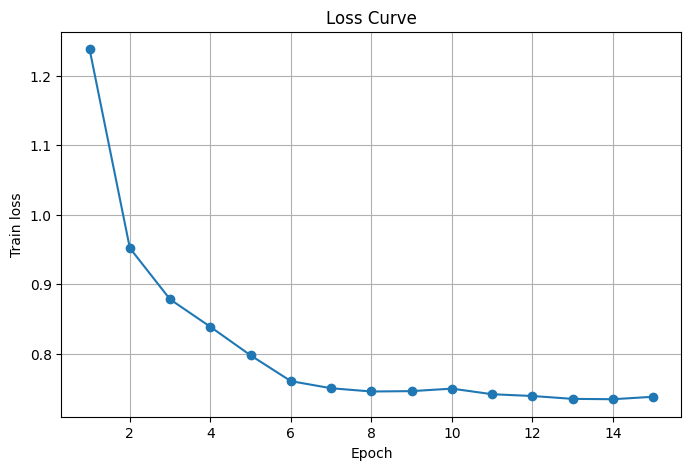

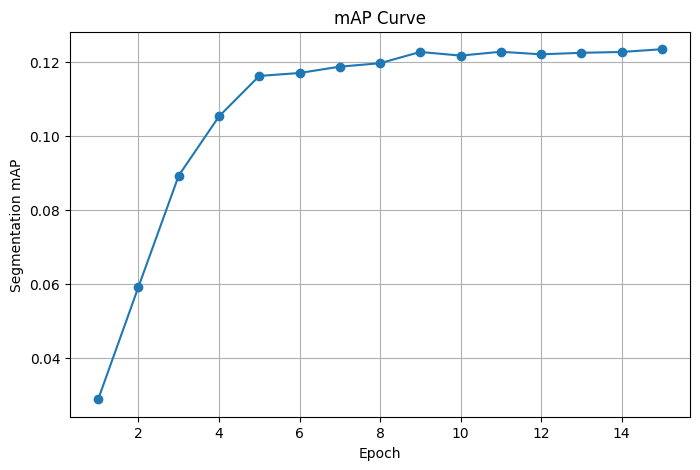

Training selesai.
Best model: outputs/best_model.pth
Last model: outputs/last_model.pth
Metrics: outputs/metrics.json


In [11]:
history = []
best_map = -1.0

for epoch in range(1, NUM_EPOCHS + 1):
    train_summary = train_one_epoch(
        model=model,
        optimizer=optimizer,
        data_loader=train_loader,
        device=DEVICE,
        epoch=epoch
    )

    lr_scheduler.step()

    record = {
        "epoch": epoch,
        "train_loss": train_summary["loss"],
        "lr": optimizer.param_groups[0]["lr"]
    }

    for key, value in train_summary.items():

        
        if key != "loss":
            record[f"train_{key}"] = value

    if epoch % EVAL_EVERY == 0:
        eval_summary = evaluate_coco(
            model=model,
            data_loader=test_loader,
            dataset=test_dataset,
            device=DEVICE,
            score_threshold=0.05,
            mask_threshold=MASK_THRESHOLD
        )

        bbox_ap = eval_summary["bbox"]["AP"]
        segm_ap = eval_summary["segm"]["AP"]

        record["bbox_AP"] = bbox_ap
        record["bbox_AP50"] = eval_summary["bbox"]["AP50"]
        record["segm_AP"] = segm_ap
        record["segm_AP50"] = eval_summary["segm"]["AP50"]

        if segm_ap > best_map:
            best_map = segm_ap
            save_checkpoint(
                path=OUTPUT_DIR / "best_model.pth",
                model=model,
                optimizer=optimizer,
                epoch=epoch,
                categories=train_dataset.label_names,
                history=history + [record]
            )
            print(f"Best model diperbarui pada epoch {epoch}. segm_AP={segm_ap:.4f}")

    history.append(record)

    save_checkpoint(
        path=OUTPUT_DIR / "last_model.pth",
        model=model,
        optimizer=optimizer,
        epoch=epoch,
        categories=train_dataset.label_names,
        history=history
    )

    save_metrics(OUTPUT_DIR / "metrics.json", history)

    print(record)

plot_history(history)
print("Training selesai.")
print("Best model:", OUTPUT_DIR / "best_model.pth")
print("Last model:", OUTPUT_DIR / "last_model.pth")
print("Metrics:", OUTPUT_DIR / "metrics.json")

## 10. Evaluasi Akhir dan Simpan Prediksi Contoh

In [12]:
def load_checkpoint_weights(model, checkpoint_path: Path, device):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    state_dict = checkpoint.get("model_state_dict", checkpoint)
    model.load_state_dict(state_dict)
    return checkpoint


best_model_path = OUTPUT_DIR / "best_model.pth"

if best_model_path.exists():
    checkpoint = load_checkpoint_weights(model, best_model_path, DEVICE)
    print("Loaded checkpoint epoch:", checkpoint.get("epoch", "unknown"))

final_metrics = evaluate_coco(
    model=model,
    data_loader=test_loader,
    dataset=test_dataset,
    device=DEVICE,
    score_threshold=0.05,
    mask_threshold=MASK_THRESHOLD
)

with open(OUTPUT_DIR / "final_evaluation.json", "w", encoding="utf-8") as file:
    json.dump(final_metrics, file, indent=2)

print(json.dumps(final_metrics, indent=2))

Loaded checkpoint epoch: 15


Evaluating:   0%|          | 0/400 [00:00<?, ?it/s]

Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=2.06s).
Accumulating evaluation results...
DONE (t=0.18s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.192
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.312
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.212
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.076
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.243
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.237
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.171
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.314
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.328
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

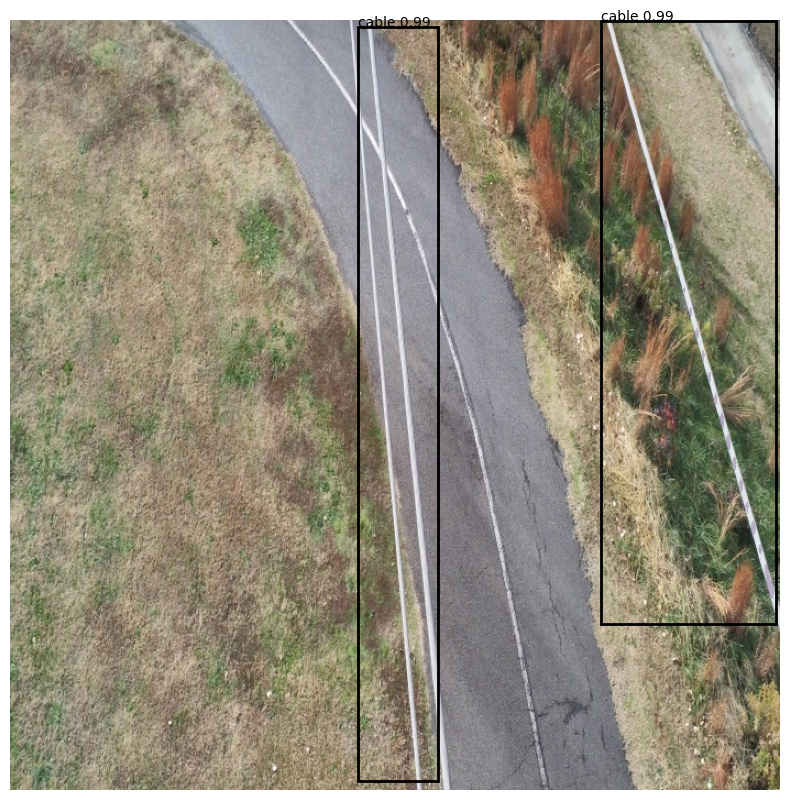

Prediksi contoh tersimpan di: outputs/predictions/sample_prediction.png


In [13]:
def draw_predictions(
    image_tensor,
    prediction,
    label_names: dict,
    score_threshold: float = 0.5,
    mask_threshold: float = 0.5,
    save_path: Path | None = None
):
    image = image_tensor.permute(1, 2, 0).cpu().numpy()

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(image)
    ax.axis("off")

    boxes = prediction["boxes"].detach().cpu().numpy()
    labels = prediction["labels"].detach().cpu().numpy()
    scores = prediction["scores"].detach().cpu().numpy()
    masks = prediction["masks"].detach().cpu().numpy()

    for box, label, score, mask in zip(boxes, labels, scores, masks):
        if float(score) < score_threshold:
            continue

        x1, y1, x2, y2 = box
        rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            fill=False,
            linewidth=2
        )
        ax.add_patch(rect)

        class_name = label_names.get(int(label), str(label))
        ax.text(x1, y1, f"{class_name} {score:.2f}", fontsize=10)

        binary_mask = mask[0] >= mask_threshold
        masked = np.ma.masked_where(binary_mask == 0, binary_mask)
        ax.imshow(masked, alpha=0.25)

    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")

    plt.show()


model.eval()
image_tensor, target = test_dataset[0]

with torch.no_grad():
    prediction = model([image_tensor.to(DEVICE)])[0]

save_path = PREDICTION_DIR / "sample_prediction.png"
draw_predictions(
    image_tensor=image_tensor,
    prediction=prediction,
    label_names=test_dataset.label_names,
    score_threshold=SCORE_THRESHOLD,
    mask_threshold=MASK_THRESHOLD,
    save_path=save_path
)

print("Prediksi contoh tersimpan di:", save_path)

In [17]:
!zip -r /content/outputs.zip /content/outputs

  adding: content/outputs/ (stored 0%)
  adding: content/outputs/last_model.pth (deflated 7%)
  adding: content/outputs/best_model.pth (deflated 7%)
  adding: content/outputs/final_evaluation.json (deflated 58%)
  adding: content/outputs/metrics.json (deflated 73%)
  adding: content/outputs/loss_curve.png (deflated 9%)
  adding: content/outputs/predictions/ (stored 0%)
  adding: content/outputs/predictions/sample_prediction.png (deflated 0%)
  adding: content/outputs/map_curve.png (deflated 10%)


In [19]:
from google.colab import files

files.download("/content/outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import auth
auth.authenticate_user()

from googleapiclient.discovery import build
from googleapiclient.http import MediaFileUpload
from pathlib import Path

# File yang mau diupload
file_path = "/content/outputs.zip"

# Folder Google Drive tujuan
folder_id = "1i4REGSRkwIlNxzezygrda5Hc0fNWuYRx"

# Nama file di Google Drive
drive_filename = "outputs_maskrcnn_torchvision.zip"

# Cek file ada atau tidak
if not Path(file_path).exists():
    raise FileNotFoundError(f"File tidak ditemukan: {file_path}")

drive_service = build("drive", "v3")

file_metadata = {
    "name": drive_filename,
    "parents": [folder_id]
}

media = MediaFileUpload(
    file_path,
    mimetype="application/zip",
    resumable=True
)

request = drive_service.files().create(
    body=file_metadata,
    media_body=media,
    fields="id, name, webViewLink"
)

response = None
while response is None:
    status, response = request.next_chunk()
    if status:
        print(f"Upload progress: {int(status.progress() * 100)}%")

print("Upload selesai.")
print("Nama file:", response["name"])
print("File ID:", response["id"])
print("Link:", response["webViewLink"])

Upload progress: 15%
Upload progress: 31%
Upload progress: 47%
Upload progress: 63%
Upload progress: 79%
Upload progress: 95%
Upload selesai.
Nama file: outputs_maskrcnn_torchvision.zip
File ID: 167ng5-QvQPXguD3o1RiLYYkHFv0g7YK6
Link: https://drive.google.com/file/d/167ng5-QvQPXguD3o1RiLYYkHFv0g7YK6/view?usp=drivesdk


In [ ]:
from pathlib import Path

files_to_save = [
    "/content/outputs/best_model.pth",
    "/content/outputs/last_model.pth",
    "/content/outputs/metrics.json"
]

for file in files_to_save:
    path = Path(file)
    print(file, "ADA" if path.exists() else "TIDAK ADA", f"{path.stat().st_size / (1024*1024):.2f} MB" if path.exists() else "")